In [3]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [4]:
torch.backends.mkldnn.enabled = True

In [5]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [6]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [7]:
model9_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model9_0)
describe(model9_0)

MACs: 7.73 MMac, Params: 48.51 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model9_0.pt
Starting
Epoch 1/60: Train loss = 1.0962, Train accuracy = 0.6102, Test loss = 1.0573, Test accuracy = 0.6283
Epoch 2/60: Train loss = 0.8687, Train accuracy = 0.6927, Test loss = 0.8523, Test accuracy = 0.7054
Epoch 3/60: Train loss = 0.8233, Train accuracy = 0.7145, Test loss = 0.8392, Test accuracy = 0.7163
Epoch 4/60: Train loss = 0.7335, Train accuracy = 0.7440, Test loss = 0.7413, Test accuracy = 0.7489
Epoch 5/60: Train loss = 0.7118, Train accuracy = 0.7523, Test loss = 0.7151, Test accuracy = 0.7647
Epoch 6/60: Train loss = 0.6318, Train accuracy = 0.7803, Test loss = 0.6568, Test accuracy = 0.7743
Epoch 7/60: Train loss = 0.6252, Train accuracy = 0.7814, Test loss = 0.6544, Test accuracy = 0.7776
Epoch 8/60: Train loss = 0.6221, Train accuracy = 0.7837, Test loss = 0.6691, Test accuracy = 0.7759
Epoch 9/60: Train loss = 0.5729, Train accuracy = 0.8010, Test loss = 0.6204, Test accuracy = 0.7954
Epoch 10/60: Train loss = 0.5378

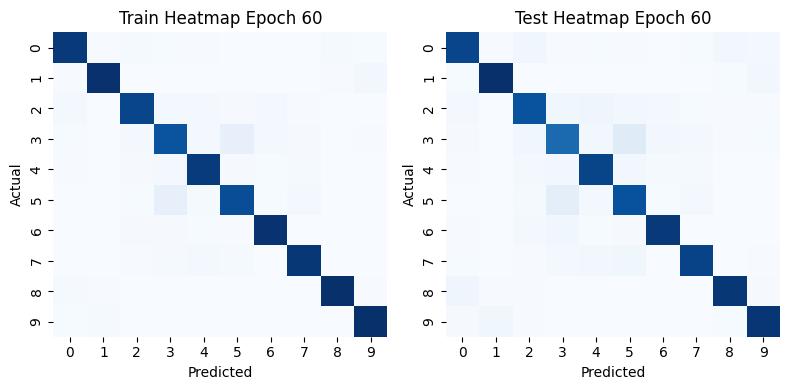

<Figure size 1200x600 with 0 Axes>

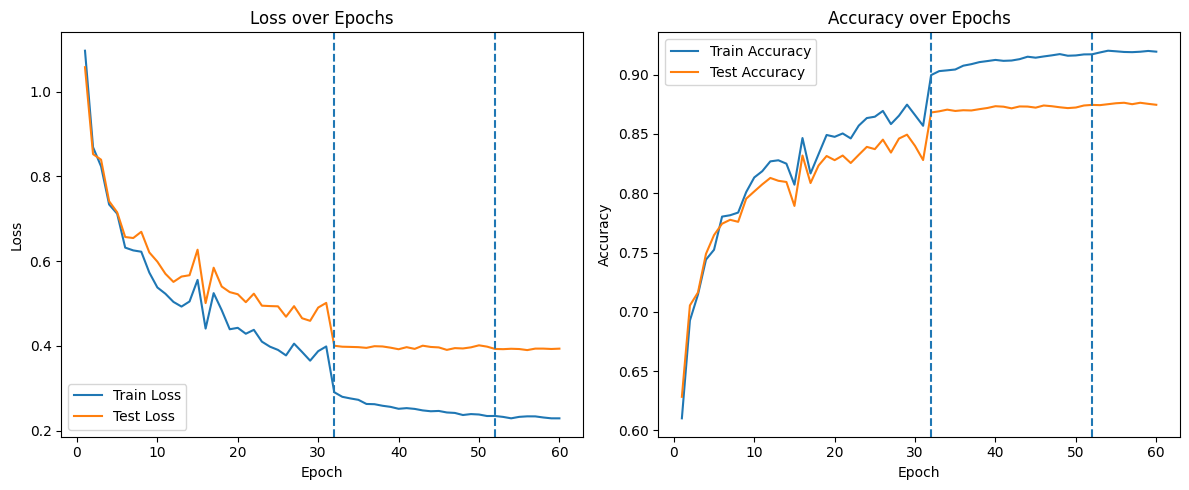

In [8]:
trainf32(model9_0,"model_weights/model9_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [9]:
model9_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model9_1)
describe(model9_1)

MACs: 7.73 MMac, Params: 48.51 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model9_1.pt
Starting
Epoch 1/60: Train loss = 1.1691, Train accuracy = 0.6065, Test loss = 1.1907, Test accuracy = 0.6093
Epoch 2/60: Train loss = 0.8077, Train accuracy = 0.7198, Test loss = 0.7945, Test accuracy = 0.7282
Epoch 3/60: Train loss = 0.6891, Train accuracy = 0.7586, Test loss = 0.6945, Test accuracy = 0.7583
Epoch 4/60: Train loss = 0.7311, Train accuracy = 0.7524, Test loss = 0.7744, Test accuracy = 0.7450
Epoch 5/60: Train loss = 0.6448, Train accuracy = 0.7721, Test loss = 0.6638, Test accuracy = 0.7728
Epoch 6/60: Train loss = 0.5825, Train accuracy = 0.7963, Test loss = 0.6218, Test accuracy = 0.7834
Epoch 7/60: Train loss = 0.5490, Train accuracy = 0.8103, Test loss = 0.5598, Test accuracy = 0.8064
Epoch 8/60: Train loss = 0.5560, Train accuracy = 0.8067, Test loss = 0.5888, Test accuracy = 0.7960
Epoch 9/60: Train loss = 0.5275, Train accuracy = 0.8162, Test loss = 0.5643, Test accuracy = 0.8069
Epoch 10/60: Train loss = 0.5111

/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 14/60: Train loss = 0.4511, Train accuracy = 0.8442, Test loss = 0.5137, Test accuracy = 0.8252
Epoch 15/60: Train loss = 0.4593, Train accuracy = 0.8387, Test loss = 0.5044, Test accuracy = 0.8297
Epoch 16/60: Train loss = 0.4494, Train accuracy = 0.8455, Test loss = 0.5044, Test accuracy = 0.8283
Epoch 17/60: Train loss = 0.4494, Train accuracy = 0.8434, Test loss = 0.5174, Test accuracy = 0.8239
Epoch 18/60: Train loss = 0.4075, Train accuracy = 0.8592, Test loss = 0.4763, Test accuracy = 0.8369
Epoch 19/60: Train loss = 0.4100, Train accuracy = 0.8569, Test loss = 0.4642, Test accuracy = 0.8385
Epoch 20/60: Train loss = 0.4186, Train accuracy = 0.8547, Test loss = 0.4785, Test accuracy = 0.8385
Epoch 21/60: Train loss = 0.4579, Train accuracy = 0.8418, Test loss = 0.5427, Test accuracy = 0.8192
Epoch 22/60: Train loss = 0.4081, Train accuracy = 0.8588, Test loss = 0.4856, Test accuracy = 0.8359
Epoch 23/60: Train loss = 0.3899, Train accuracy = 0.8621, Test loss = 0.4648, Tes

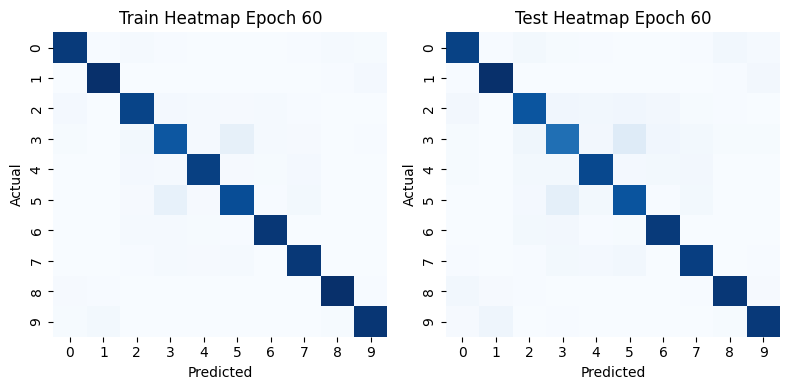

<Figure size 1200x600 with 0 Axes>

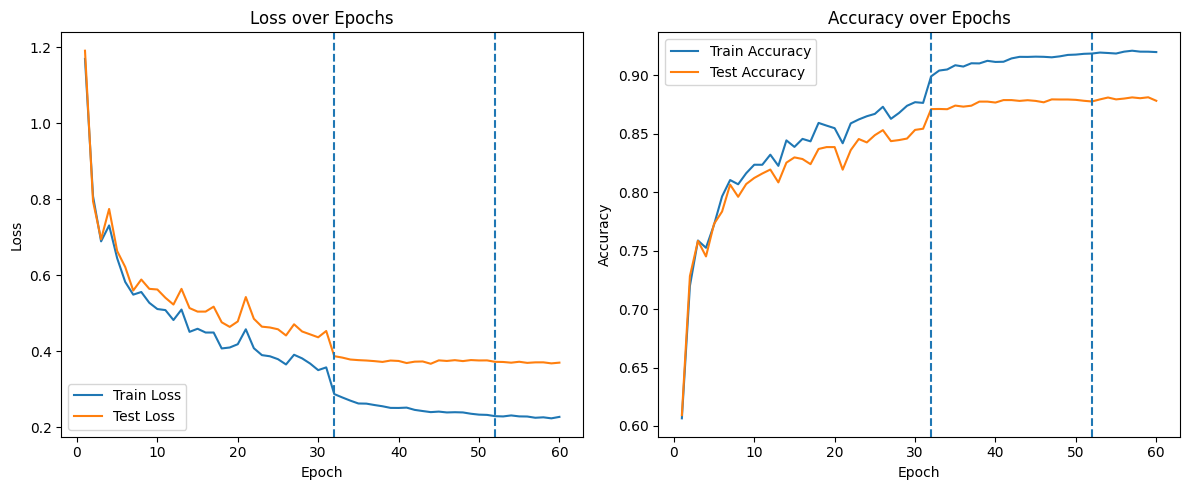

In [10]:
trainf32(model9_1,"model_weights/model9_1.pt",criterion,train_dataset,val_dataset, batch_size=64)